In [ ]:
#Connecting colab with google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Basic data cleaning

#Loading the cleaned dataset, data source coming from R package NHANES, used the cleaned dataset
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/nhanes_cleaned.csv')

#Basic data cleaning, keeping only 1 ID with the earliest survey year
import numpy as np
df = df.sort_values(["ID", "SurveyYr"])
df = df.drop_duplicates("ID", keep="first")

#Coding diabete results as binary
df["diabetes_binary"] = df["Diabetes"].map({"Yes": 1, "No": 0})
df = df.dropna(subset=["diabetes_binary"])

df["diabetes_factor"] = df["diabetes_binary"].map({0: "No", 1: "Yes"})

#Removing column with duplicate information:
df = df.drop(columns=["ID","SurveyYr","AgeDecade","AgeMonths","Race3","BPSys1",	"BPDia1",	"BPSys2",	"BPDia2",	"BPSys3",	"BPDia3"])
df.head(20)


,Gender,Age,Race1,Education,MaritalStatus,HHIncome,HHIncomeMid,Poverty,HomeRooms,HomeOwn,...,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation,PregnantNow,diabetes_binary,diabetes_factor
0,male,34,White,High School,Married,25000-34999,30000.0,1.36,6.0,Own,...,Yes,Yes,16.0,8.0,1.0,No,Heterosexual,NaN,0.0,No
3,male,4,Other,NaN,NaN,20000-24999,22500.0,1.07,9.0,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
4,female,49,White,Some College,LivePartner,35000-44999,40000.0,1.91,5.0,Rent,...,Yes,Yes,12.0,10.0,1.0,Yes,Heterosexual,NaN,0.0,No
5,male,9,White,NaN,NaN,75000-99999,87500.0,1.84,6.0,Rent,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
6,male,8,White,NaN,NaN,55000-64999,60000.0,2.33,7.0,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
7,female,45,White,College Grad,Married,75000-99999,87500.0,5.00,6.0,Own,...,No,Yes,13.0,20.0,0.0,Yes,Bisexual,NaN,0.0,No
10,male,66,White,Some College,Married,25000-34999,30000.0,2.20,5.0,Own,...,No,Yes,17.0,15.0,NaN,No,NaN,NaN,0.0,No
11,male,58,White,College Grad,Divorced,more 99999,100000.0,5.00,10.0,Rent,...,Yes,Yes,22.0,7.0,1.0,No,Heterosexual,NaN,0.0,No
12,male,54,White,9 - 11th Grade,Married,65000-74999,70000.0,2.20,6.0,Rent,...,Yes,Yes,12.0,100.0,1.0,No,Heterosexual,NaN,0.0,No
13,female,10,White,NaN,NaN,NaN,NaN,NaN,10.0,Own,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No


In [ ]:
#Summary statistics and EDA
import numpy as np

#checking for non-zero variance
threshold = 0.97

def top_pct(s):
    vc = s.value_counts(dropna=True)
    if vc.empty:
        return np.nan
    return vc.iloc[0] / vc.sum()

nzv = []
for c in df.columns:
    if c == "diabetes_binary":
        continue
    p = top_pct(df[c])
    if pd.notna(p) and p > threshold:
        nzv.append((c, p))

nzv
#returned nothing at threshold of 0.99 and 0.98

#displaying all rows
pd.set_option("display.max_rows", None)
#Missingness check + summary statistics
summary = pd.DataFrame({
    "col": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_n": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values,
    "n_unique": df.nunique(dropna=True).values,
})

num_cols = df.select_dtypes(include="number").columns
stats = (df[num_cols].agg(["count","min","max","mean","median","std"]).T
         .rename(columns={"count":"n_non_missing","std":"sd"})
         .round(2))

summary = summary.merge(stats, left_on="col", right_index=True, how="left")
summary = summary.sort_values("missing_pct", ascending=True)
summary



,col,dtype,missing_n,missing_pct,n_unique,n_non_missing,min,max,mean,median,sd
0,Gender,object,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN
1,Age,int64,0,0.00,80,6653.0,1.00,80.00,36.11,34.00,22.81
2,Race1,object,0,0.00,5,NaN,NaN,NaN,NaN,NaN,NaN
28,Diabetes,object,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN
66,diabetes_factor,object,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN
65,diabetes_binary,float64,0,0.00,2,6653.0,0.00,1.00,0.08,0.00,0.28
9,HomeOwn,object,43,0.65,3,NaN,NaN,NaN,NaN,NaN,NaN
8,HomeRooms,float64,47,0.71,13,6606.0,1.00,13.00,6.15,6.00,2.24
11,Weight,float64,55,0.83,1249,6598.0,8.00,230.70,70.22,71.80,28.99
14,Height,float64,174,2.62,980,6479.0,83.60,200.40,160.35,165.10,21.13


In [ ]:
# EDA Missing % + Skewness + Correlation with target + Multicollinearity

y_col = "diabetes_binary"
mc_threshold = 0.80  # |r| threshold for multicollinearity

# numeric predictors only (exclude target)
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != y_col]

# ---- 1) Core metrics ----
missing_pct = (df[num_cols].isna().mean() * 100).round(2)
skew_abs = df[num_cols].skew(numeric_only=True).abs()

corr_with_target = df[num_cols].corrwith(df[y_col]).dropna()
abs_corr_with_target = corr_with_target.abs()

report = pd.DataFrame({
    "variable": num_cols,
    "missing_%": missing_pct.reindex(num_cols).values,
    "correlation": corr_with_target.reindex(num_cols).values,
    "abs_corr": abs_corr_with_target.reindex(num_cols).values,
    "abs_skewness": skew_abs.reindex(num_cols).values,
}).sort_values("abs_corr", ascending=False)

pd.set_option("display.max_rows", None)
print("=" * 80)
print("VARIABLE SUMMARY (Missing % + Skewness + Corr w/ Target)")
print("=" * 80)
print(report.to_string(index=False))

# ---- 2) Multicollinearity (pairwise) ----
corr_matrix = df[num_cols].corr().abs()

# keep only upper triangle to avoid duplicates/self-corr
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "abs_corr_pair"})
)

high_corr_pairs = pairs[pairs["abs_corr_pair"] > mc_threshold].copy()
high_corr_pairs["abs_corr_pair"] = high_corr_pairs["abs_corr_pair"].round(3)

# suggest which to drop: drop the one with weaker correlation to target
def suggest_drop(row):
    v1, v2 = row["var1"], row["var2"]
    c1 = abs(corr_with_target.get(v1, 0))
    c2 = abs(corr_with_target.get(v2, 0))
    return v1 if c1 < c2 else v2

if not high_corr_pairs.empty:
    high_corr_pairs["drop_suggestion"] = high_corr_pairs.apply(suggest_drop, axis=1)
    high_corr_pairs = high_corr_pairs.sort_values("abs_corr_pair", ascending=False)

    print("\n" + "=" * 80)
    print(f"HIGH MULTICOLLINEARITY (|r| > {mc_threshold})")
    print("=" * 80)
    print(high_corr_pairs.to_string(index=False))
else:
    print("\nNo feature pairs found with |r| >", mc_threshold)


VARIABLE SUMMARY (Missing % + Skewness + Corr w/ Target)
       variable  missing_%  correlation  abs_corr  abs_skewness
            Age       0.00     0.317106  0.317106      0.251045
            BMI       2.71     0.238033  0.238033      0.963458
         Weight       0.83     0.208802  0.208802      0.058568
       BPSysAve      15.23     0.205626  0.205626      1.052141
DaysPhysHlthBad      26.51     0.176562  0.176562      2.604528
        nBabies      76.31     0.158825  0.158825      1.602923
   nPregnancies      74.52     0.149085  0.149085      3.164334
         Height       2.62     0.094711  0.094711      1.561613
     DirectChol      15.92    -0.092647  0.092647      1.014671
    AlcoholYear      43.95    -0.083855  0.083855      1.665548
    HHIncomeMid       8.58    -0.080462  0.080462      0.178427
    AgeRegMarij      87.57     0.079541  0.079541      2.779758
     Age1stBaby      81.30    -0.058280  0.058280      0.657006
     UrineFlow2      85.38    -0.052338  0.0523

In [ ]:
#Variable selection, removing variables with high missingness (>70), strong colinearity, and high skewness

all_deletions = [
    # Collinearity - redundant variables
    'Length', 'Poverty', 'Weight',
    # Missingness - high missing values
    'AgeRegMarij', 'UrineFlow2', 'CompHrsDayChild', 'TVHrsDayChild',
    'AgeFirstMarij', 'SmokeAge', 'UrineVol2', 'HeadCirc', 'DiabetesAge'
]

df = df.drop(columns=all_deletions)

df.head(20)

,Gender,Age,Race1,Education,MaritalStatus,HHIncome,HHIncomeMid,HomeRooms,HomeOwn,Work,...,HardDrugs,SexEver,SexAge,SexNumPartnLife,SexNumPartYear,SameSex,SexOrientation,PregnantNow,diabetes_binary,diabetes_factor
0,male,34,White,High School,Married,25000-34999,30000.0,6.0,Own,NotWorking,...,Yes,Yes,16.0,8.0,1.0,No,Heterosexual,NaN,0.0,No
3,male,4,Other,NaN,NaN,20000-24999,22500.0,9.0,Own,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
4,female,49,White,Some College,LivePartner,35000-44999,40000.0,5.0,Rent,NotWorking,...,Yes,Yes,12.0,10.0,1.0,Yes,Heterosexual,NaN,0.0,No
5,male,9,White,NaN,NaN,75000-99999,87500.0,6.0,Rent,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
6,male,8,White,NaN,NaN,55000-64999,60000.0,7.0,Own,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No
7,female,45,White,College Grad,Married,75000-99999,87500.0,6.0,Own,Working,...,No,Yes,13.0,20.0,0.0,Yes,Bisexual,NaN,0.0,No
10,male,66,White,Some College,Married,25000-34999,30000.0,5.0,Own,NotWorking,...,No,Yes,17.0,15.0,NaN,No,NaN,NaN,0.0,No
11,male,58,White,College Grad,Divorced,more 99999,100000.0,10.0,Rent,Working,...,Yes,Yes,22.0,7.0,1.0,No,Heterosexual,NaN,0.0,No
12,male,54,White,9 - 11th Grade,Married,65000-74999,70000.0,6.0,Rent,Working,...,Yes,Yes,12.0,100.0,1.0,No,Heterosexual,NaN,0.0,No
13,female,10,White,NaN,NaN,NaN,NaN,10.0,Own,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,No


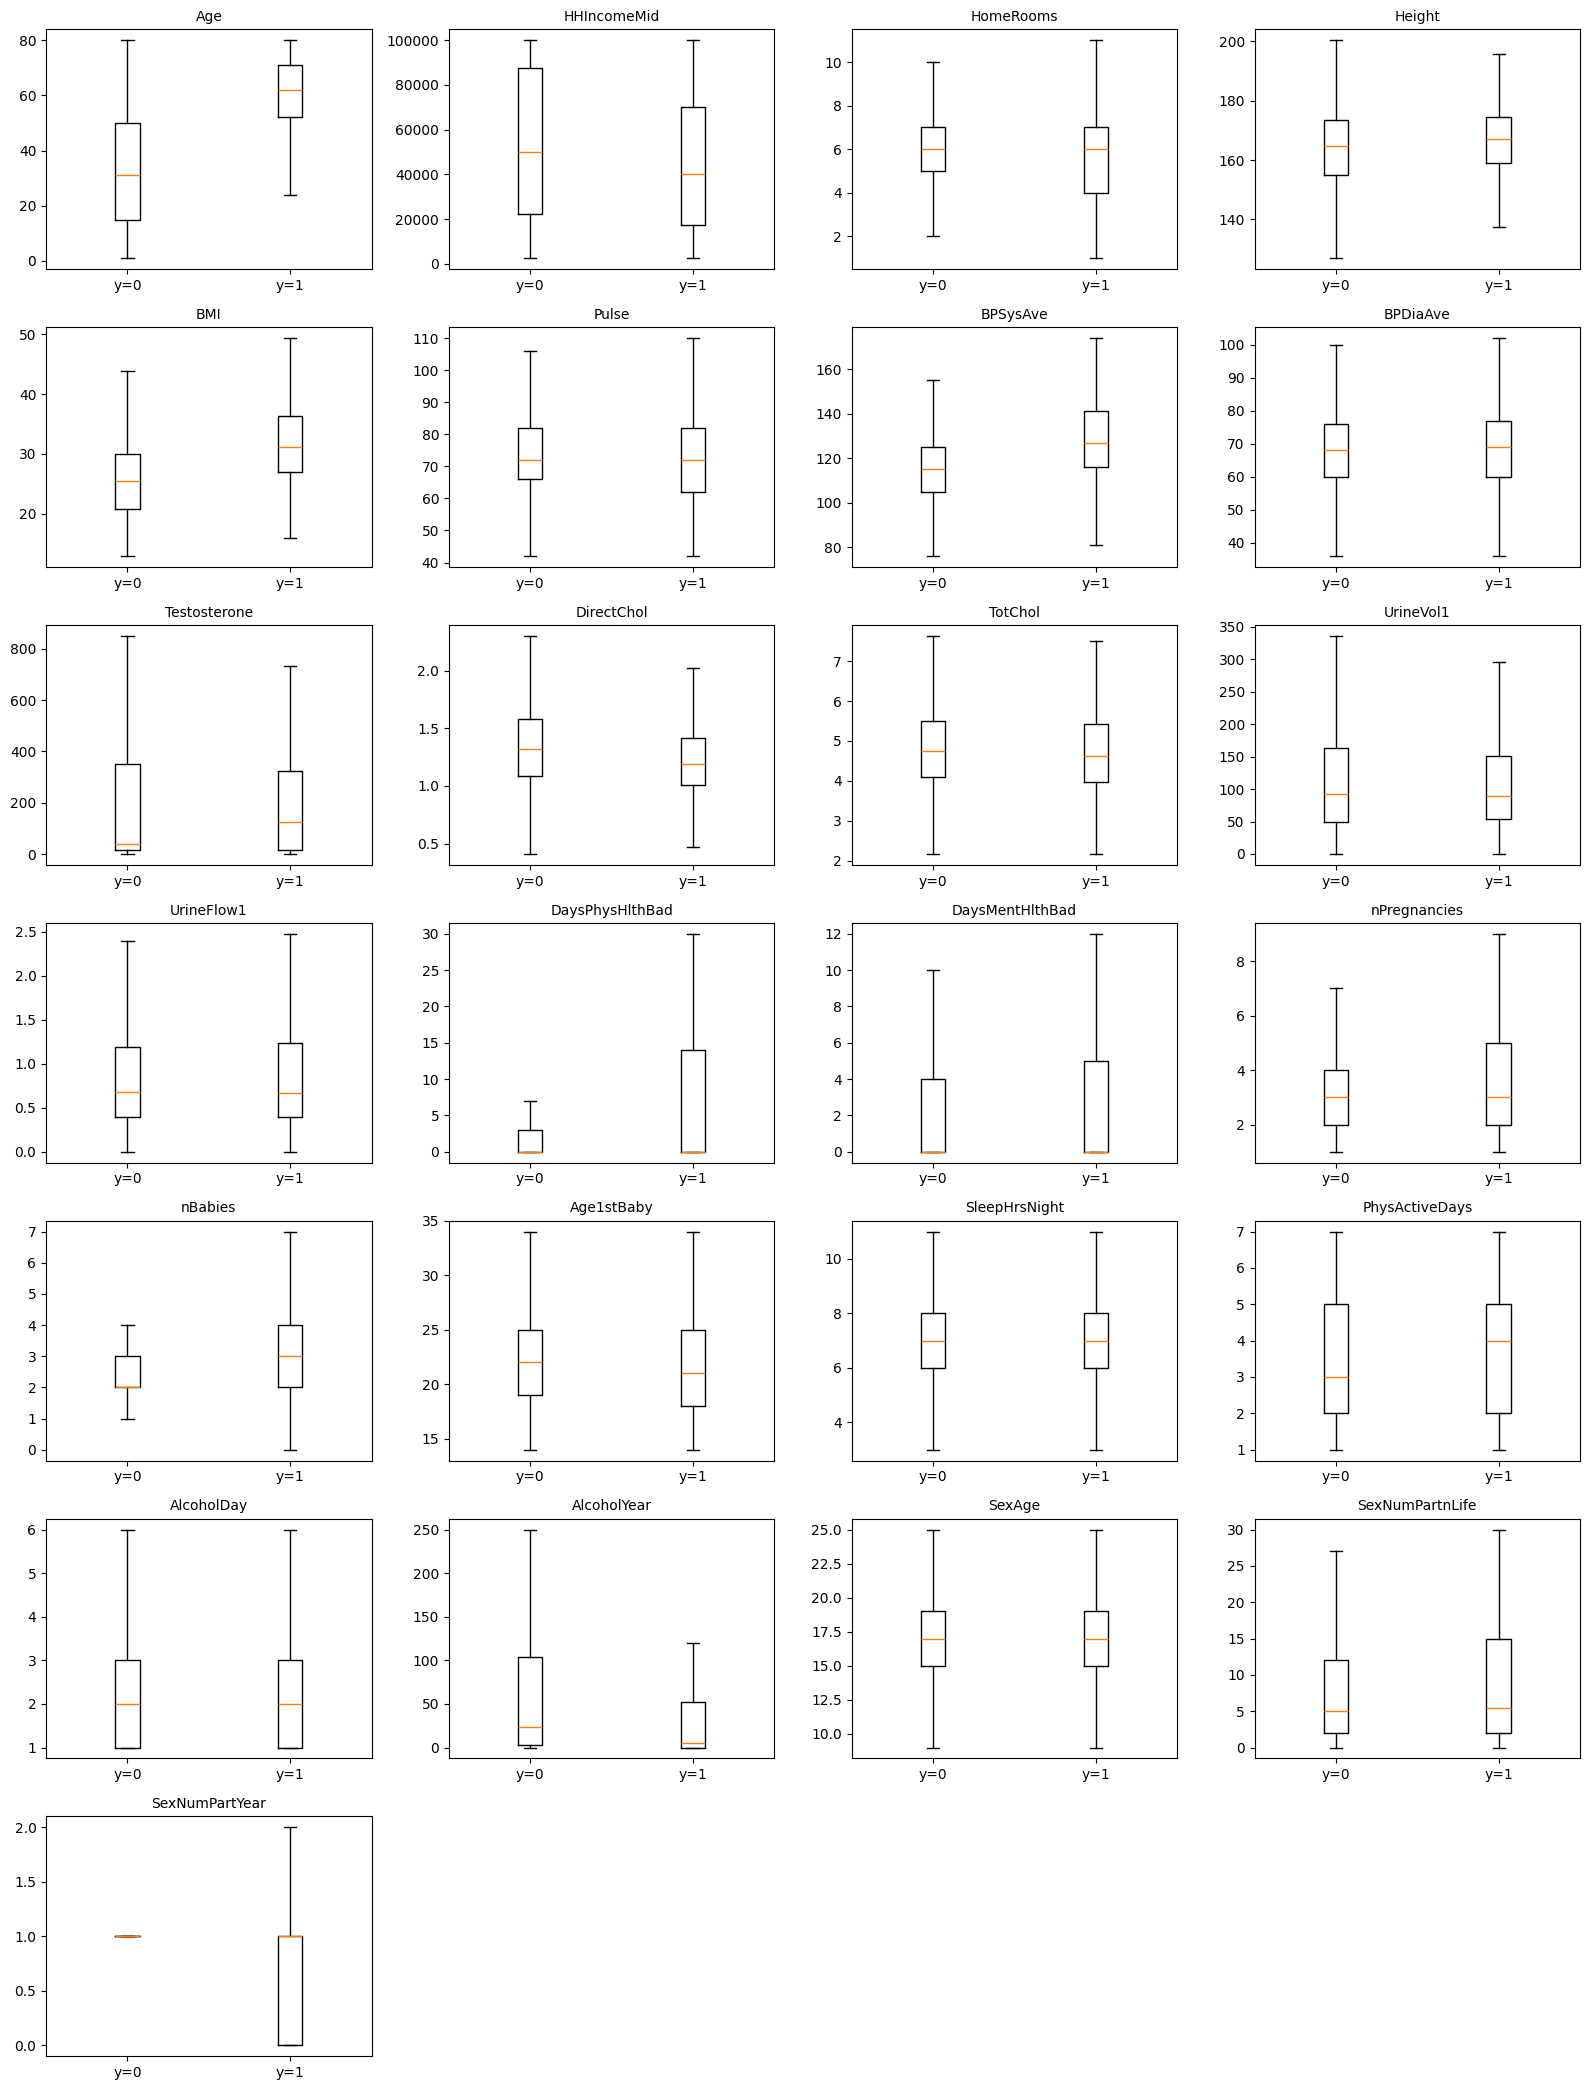

In [ ]:
#Code with boxplot
import matplotlib.pyplot as plt

y_col = "diabetes_binary"

# numeric predictors only
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c != y_col]

# how many plots per row
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows))
axes = np.array(axes).reshape(-1)

# split by y once
g0 = df[df[y_col] == 0]
g1 = df[df[y_col] == 1]

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = [g0[col].dropna(), g1[col].dropna()]
    ax.boxplot(data, labels=["y=0", "y=1"], showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelrotation=0)

# hide any extra axes
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

#Summary:
#Results show that Age, BMI, BPSysAve might be strong predictor
#Variables such as Testosterone, UrineVol1, UrineFlow1, DaysPhysHithBad, DaysMentHithBad, nPregancies,
#nBabies, AlchoholDay, AlchoholYear,SexNumParLife need to be log transformed
#SexNumPartner to be removed

#From previous chunk of code, variables related to gender, Age1stBaby, nPregancies, nBabies need to be
#coded differently during imputation

In [ ]:
#Experiment 1: complete case analysis (no imputation)
#Only compare logistic vs. XGB
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, roc_curve
from xgboost import XGBClassifier

TARGET = "diabetes_binary"
LOG_VARS = ["Testosterone","UrineVol1","UrineFlow1","DaysPhysHlthBad","DaysMentHlthBad",
            "nPregnancies","nBabies","AlcoholDay","AlcoholYear","SexNumParLife"]
DROP_VARS = ["SexNumPartner"]  # remove
K = 5
RS = 42

def fe_complete_case(X_tr, X_te, y_tr, y_te):
    X_tr, X_te = X_tr.drop(columns=DROP_VARS, errors="ignore").copy(), X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    # log1p (neg -> NaN so complete-case drops)
    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr.loc[X_tr[v] < 0, v] = np.nan
            X_te.loc[X_te[v] < 0, v] = np.nan
            X_tr[v], X_te[v] = np.log1p(X_tr[v]), np.log1p(X_te[v])

    # one-hot + align to train columns
    cat = X_tr.select_dtypes(include=["object","category","bool"]).columns
    if len(cat):
        X_tr = pd.get_dummies(X_tr, columns=cat, drop_first=True)
        X_te = pd.get_dummies(X_te, columns=cat, drop_first=True).reindex(columns=X_tr.columns, fill_value=0)

    # complete-case per split
    mtr = X_tr.notna().all(axis=1)
    mte = X_te.notna().all(axis=1)

    return X_tr[mtr].reset_index(drop=True), X_te[mte].reset_index(drop=True), y_tr[mtr].reset_index(drop=True), y_te[mte].reset_index(drop=True)

def youden_threshold(y_true, proba):
    fpr, tpr, thr = roc_curve(y_true, proba)
    return thr[np.argmax(tpr - fpr)]  # Youden = TPR - FPR

def metrics_at_thr(y, proba, thr):
    pred = (proba >= thr).astype(int)
    return dict(
        Recall=recall_score(y, pred, zero_division=0),
        Precision=precision_score(y, pred, zero_division=0),
        F1=f1_score(y, pred, zero_division=0),
        PRAUC=average_precision_score(y, proba),
        Thr=float(thr)
    )

def run_cv(df, all_deletions=None):
    dfm = df.drop(columns=all_deletions or [], errors="ignore")
    X = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y = dfm[TARGET].astype(int)

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RS)
    rows = []

    for model_name in ["Logistic", "XGBoost"]:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            # FE + complete-case
            Xtr, Xte, ytr, yte = fe_complete_case(Xtr0, Xte0, ytr0, yte0)
            if len(np.unique(ytr)) < 2 or len(np.unique(yte)) < 2:
                continue

            # inner split on TRAIN to pick threshold (no test leakage)
            Xsub, Xval, ysub, yval = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS)

            if model_name == "Logistic":
                sc = StandardScaler()
                Xsub_s, Xval_s, Xtr_s, Xte_s = sc.fit_transform(Xsub), sc.transform(Xval), sc.transform(Xtr), sc.transform(Xte)

                m = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RS)
                m.fit(Xsub_s, ysub)
                thr = youden_threshold(yval, m.predict_proba(Xval_s)[:, 1])

                m.fit(Xtr_s, ytr)
                proba = m.predict_proba(Xte_s)[:, 1]

            else:
                # imbalance handling in XGB via scale_pos_weight (neg/pos) on training fold
                spw = ((ytr == 0).sum() / max(1, (ytr == 1).sum()))
                m = XGBClassifier(
                    n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                    scale_pos_weight=spw, eval_metric="logloss", n_jobs=-1, random_state=RS
                )
                m.fit(Xsub, ysub)
                thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

                m.fit(Xtr, ytr)
                proba = m.predict_proba(Xte)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr))

        # aggregate
        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall","Precision","F1","PRAUC","Thr"]}
        agg_sd = {k+"_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall","Precision","F1","PRAUC"]}
        rows.append({"Model": model_name, "Folds": len(fold_ms), **agg, **agg_sd})

    return pd.DataFrame(rows).sort_values("Recall", ascending=False)

# usage:
res = run_cv(df, all_deletions=all_deletions)
print(res.to_string(index=False))

#Result:
#5-fold 里 只有 3 个 fold 被算进去了（Folds = 3），另外 2 个 fold 在代码里被 continue 跳过了
#通常是 complete-case 之后某个 fold 的 train 或 test 里只剩一个类别、样本太少、或者 y 全 0/全 1



   Model  Folds   Recall  Precision       F1    PRAUC      Thr  Recall_SD  Precision_SD    F1_SD  PRAUC_SD
Logistic      3 0.555556   0.132275 0.200000 0.352116 0.157890    0.41574      0.117598 0.163299  0.159420
 XGBoost      3 0.555556   0.155844 0.235897 0.396970 0.039751    0.41574      0.118079 0.171009  0.239847


In [ ]:
#Experiment 2: Simple imputation +class imbalance handling
#Only Baseline model vs. logistic vs. XGB

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC

# ----------------
# Config
# ----------------
TARGET = "diabetes_binary"
K, RS = 5, 42

LOG_VARS = [
    "Testosterone", "UrineVol1", "UrineFlow1", "DaysPhysHlthBad", "DaysMentHlthBad",
    "nPregnancies", "nBabies", "AlcoholDay", "AlcoholYear", "SexNumParLife"
]
DROP_VARS = ["SexNumPartner"]

GENDER_COL = "Gender"
GENDER_SPECIFIC = ["Age1stBaby", "nPregnancies", "nBabies"]

# ----------------
# Helpers: rules / preprocess
# ----------------
def apply_gender_rule(X: pd.DataFrame) -> pd.DataFrame:
    """For male: set selected pregnancy/baby vars to 0 (domain rule)."""
    X = X.copy()
    if GENDER_COL in X.columns:
        male = X[GENDER_COL].astype(str).str.lower().eq("male")
        for v in GENDER_SPECIFIC:
            if v in X.columns:
                X.loc[male, v] = 0
    return X


def preprocess_simple_impute(X_tr, X_te, y_tr, y_te):
    """
    For Dummy / Logistic (non-SMOTENC) / XGB:
      - drop vars
      - gender rule
      - cat: mode impute -> one-hot -> align
      - num: median impute (on all columns after one-hot)
      - log1p on LOG_VARS (after impute; clip negatives to 0)
    """
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    cat_cols = X_tr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # categorical: mode impute + one-hot
    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        X_tr = pd.get_dummies(X_tr, columns=cat_cols, drop_first=True)
        X_te = pd.get_dummies(X_te, columns=cat_cols, drop_first=True)
        X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    # numeric (now everything should be numeric)
    num_cols = X_tr.columns.tolist()
    num_imp = SimpleImputer(strategy="median")
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imp.transform(X_te[num_cols])

    # log1p after impute
    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    return (
        X_tr.reset_index(drop=True),
        X_te.reset_index(drop=True),
        y_tr.reset_index(drop=True),
        y_te.reset_index(drop=True),
    )


def preprocess_for_smotenc_logistic(X_tr, X_te, y_tr, y_te):
    """
    For Logistic + SMOTENC (no one-hot):
      - drop vars
      - gender rule
      - cat: mode impute -> ordinal encode (integers)
      - num: median impute
      - log1p
      - standardize numeric ONLY (cat stays integer-coded)
    Returns:
      X_tr_mat, X_te_mat, y_tr, y_te, cat_idx
    """
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    cat_cols = X_tr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = X_tr.select_dtypes(include=["number"]).columns.tolist()

    # categorical: mode impute -> ordinal encode
    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = oe.transform(X_te[cat_cols])

    # numeric: median impute
    if len(num_cols) > 0:
        num_imp = SimpleImputer(strategy="median")
        X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
        X_te[num_cols] = num_imp.transform(X_te[num_cols])

    # log1p after impute
    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    # build matrix: numeric first, then categorical
    ordered_cols = num_cols + cat_cols
    X_tr_mat = X_tr[ordered_cols].to_numpy()
    X_te_mat = X_te[ordered_cols].to_numpy()

    num_idx = list(range(len(num_cols)))
    cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    # standardize numeric only
    if len(num_idx) > 0:
        sc = StandardScaler()
        X_tr_mat[:, num_idx] = sc.fit_transform(X_tr_mat[:, num_idx])
        X_te_mat[:, num_idx] = sc.transform(X_te_mat[:, num_idx])

    return (
        X_tr_mat,
        X_te_mat,
        y_tr.reset_index(drop=True),
        y_te.reset_index(drop=True),
        cat_idx,
    )


# ----------------
# Metrics helpers
# ----------------
def youden_threshold(y_true, proba):
    fpr, tpr, thr = roc_curve(y_true, proba)
    return thr[np.argmax(tpr - fpr)]  # Youden = TPR - FPR


def metrics_at_thr(y, proba, thr):
    pred = (proba >= thr).astype(int)
    return dict(
        Recall=recall_score(y, pred, zero_division=0),
        Precision=precision_score(y, pred, zero_division=0),
        F1=f1_score(y, pred, zero_division=0),
        PRAUC=average_precision_score(y, proba),
        Thr=float(thr),
    )


def _clone(model):
    return type(model)(**model.get_params())


# ----------------
# CV runner
# ----------------
def run_cv_simple_impute(df, all_deletions=None):
    dfm = df.drop(columns=all_deletions or [], errors="ignore")
    X = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y = dfm[TARGET].astype(int)

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RS)
    rows = []

    # =======================
    # A) Baseline: Dummy
    # =======================
    for strat in ["most_frequent", "stratified"]:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

            m = DummyClassifier(strategy=strat, random_state=RS)
            m.fit(Xtr, ytr)
            proba = m.predict_proba(Xte)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr=0.5))

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": f"Dummy_{strat}", "Imbalance": "n/a", "Folds": len(fold_ms), **agg, **agg_sd})

    # =======================
    # B) Logistic: imbalance compare
    # =======================
    LOGISTIC_IMB = ["none", "class_weight", "oversample", "smotenc"]

    for imb in LOGISTIC_IMB:
        fold_ms = []

        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            if imb == "smotenc":
                # preprocess for SMOTENC (no one-hot)
                Xtr_mat, Xte_mat, ytr, yte, cat_idx = preprocess_for_smotenc_logistic(Xtr0, Xte0, ytr0, yte0)

                Xsub, Xval, ysub, yval = train_test_split(
                    Xtr_mat, ytr, test_size=0.2, stratify=ytr, random_state=RS
                )

                def resample_nc(Xa, ya):
                    sm = SMOTENC(categorical_features=cat_idx, random_state=RS)
                    return sm.fit_resample(Xa, ya)

                # threshold on resampled sub-train
                m = LogisticRegression(max_iter=2000, random_state=RS)
                Xsub_b, ysub_b = resample_nc(Xsub, ysub)
                m.fit(Xsub_b, ysub_b)
                thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

                # final fit on resampled full train
                Xtr_b, ytr_b = resample_nc(Xtr_mat, ytr)
                m2 = _clone(m)
                m2.fit(Xtr_b, ytr_b)
                proba = m2.predict_proba(Xte_mat)[:, 1]

            else:
                # standard preprocess (one-hot)
                Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

                Xsub, Xval, ysub, yval = train_test_split(
                    Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS
                )

                sc = StandardScaler()
                Xsub_s = sc.fit_transform(Xsub)
                Xval_s = sc.transform(Xval)
                Xtr_s = sc.transform(Xtr)
                Xte_s = sc.transform(Xte)

                def resample(Xa, ya):
                    if imb == "oversample":
                        return RandomOverSampler(random_state=RS).fit_resample(Xa, ya)
                    return Xa, ya

                m = LogisticRegression(
                    max_iter=2000,
                    class_weight=("balanced" if imb == "class_weight" else None),
                    random_state=RS,
                )

                # threshold on (possibly resampled) sub-train
                Xsub_b, ysub_b = resample(Xsub_s, ysub)
                m.fit(Xsub_b, ysub_b)
                thr = youden_threshold(yval, m.predict_proba(Xval_s)[:, 1])

                # final fit on (possibly resampled) full train
                m2 = _clone(m)
                Xtr_b, ytr_b = resample(Xtr_s, ytr)
                m2.fit(Xtr_b, ytr_b)
                proba = m2.predict_proba(Xte_s)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr))

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": "Logistic", "Imbalance": imb, "Folds": len(fold_ms), **agg, **agg_sd})

    # =======================
    # C) XGBoost: imbalance compare
    # =======================
    XGB_IMB = ["none", "scale_pos_weight", "oversample", "smote"]

    for imb in XGB_IMB:
        fold_ms = []

        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)
            Xsub, Xval, ysub, yval = train_test_split(
                Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS
            )

            def resample(Xa, ya):
                if imb == "oversample":
                    return RandomOverSampler(random_state=RS).fit_resample(Xa, ya)
                if imb == "smote":
                    return SMOTE(random_state=RS).fit_resample(Xa, ya)
                return Xa, ya

            def spw(ya):
                return (ya.eq(0).sum() / max(1, ya.eq(1).sum()))

            params = dict(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                eval_metric="logloss",
                n_jobs=-1,
                random_state=RS,
            )

            # threshold on sub-train
            Xsub_b, ysub_b = resample(Xsub, ysub)
            params_sub = params.copy()
            if imb == "scale_pos_weight":
                params_sub["scale_pos_weight"] = spw(ysub_b)

            m = XGBClassifier(**params_sub)
            m.fit(Xsub_b, ysub_b)
            thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

            # final fit on full train
            Xtr_b, ytr_b = resample(Xtr, ytr)
            params_full = params.copy()
            if imb == "scale_pos_weight":
                params_full["scale_pos_weight"] = spw(ytr_b)

            m2 = XGBClassifier(**params_full)
            m2.fit(Xtr_b, ytr_b)
            proba = m2.predict_proba(Xte)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr))

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": "XGBoost", "Imbalance": imb, "Folds": len(fold_ms), **agg, **agg_sd})

    return pd.DataFrame(rows).sort_values(["Recall", "PRAUC"], ascending=False)

# Usage
res2 = run_cv_simple_impute(df, all_deletions=all_deletions)
print(res2.to_string(index=False))

#Results:
#Tree model should use oversampling

              Model        Imbalance  Folds   Recall  Precision       F1    PRAUC      Thr  Recall_SD  Precision_SD    F1_SD  PRAUC_SD
            XGBoost       oversample      5 0.875152   0.216362 0.345490 0.382550 0.169236   0.046464      0.023806 0.025513  0.033975
            XGBoost scale_pos_weight      5 0.867846   0.222299 0.353600 0.377863 0.176176   0.026088      0.013225 0.016026  0.022399
            XGBoost             none      5 0.857068   0.231474 0.362558 0.398906 0.050593   0.065833      0.025630 0.026763  0.030934
           Logistic             none      5 0.837297   0.236565 0.366588 0.387650 0.072617   0.083376      0.023376 0.023382  0.044493
           Logistic       oversample      5 0.831826   0.233781 0.359994 0.376099 0.427947   0.100429      0.038575 0.039284  0.040259
            XGBoost            smote      5 0.824472   0.261920 0.395522 0.411513 0.084920   0.066822      0.025705 0.024273  0.048187
           Logistic          smotenc      5 0.822604   

In [ ]:
#Experiment 3: Model Selection
#Tree models根据exp2的结果选定了oversample, 但logistic没有完全确定

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, roc_curve
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC


# ----------------
# Config
# ----------------
TARGET = "diabetes_binary"
K, RS = 5, 42

LOG_VARS = [
    "Testosterone", "UrineVol1", "UrineFlow1", "DaysPhysHlthBad", "DaysMentHlthBad",
    "nPregnancies", "nBabies", "AlcoholDay", "AlcoholYear", "SexNumParLife"
]
DROP_VARS = ["SexNumPartner"]

GENDER_COL = "Gender"
GENDER_SPECIFIC = ["Age1stBaby", "nPregnancies", "nBabies"]


# ----------------
# Helpers: rules / preprocess
# ----------------
def apply_gender_rule(X: pd.DataFrame) -> pd.DataFrame:
    """Domain rule: for male, set pregnancy/baby vars to 0."""
    X = X.copy()
    if GENDER_COL in X.columns:
        male = X[GENDER_COL].astype(str).str.lower().eq("male")
        for v in GENDER_SPECIFIC:
            if v in X.columns:
                X.loc[male, v] = 0
    return X


def preprocess_simple_impute(X_tr, X_te, y_tr, y_te):
    """
    For Dummy / Logistic(non-SMOTENC) / Trees / XGB:
      - drop vars
      - gender rule
      - cat: mode impute -> one-hot -> align
      - num: median impute
      - log1p (clip negatives to 0)
    """
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    cat_cols = X_tr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        X_tr = pd.get_dummies(X_tr, columns=cat_cols, drop_first=True)
        X_te = pd.get_dummies(X_te, columns=cat_cols, drop_first=True)
        X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    num_cols = X_tr.columns.tolist()
    num_imp = SimpleImputer(strategy="median")
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imp.transform(X_te[num_cols])

    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    return (
        X_tr.reset_index(drop=True),
        X_te.reset_index(drop=True),
        y_tr.reset_index(drop=True),
        y_te.reset_index(drop=True),
    )


def preprocess_for_smotenc(X_tr, X_te, y_tr, y_te):
    """
    For SMOTENC (Logistic only):
      - drop vars
      - gender rule
      - cat: mode impute -> ordinal encode
      - num: median impute
      - log1p
      - standardize numeric only
    Returns:
      X_tr_mat, X_te_mat, y_tr, y_te, cat_idx
    """
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    cat_cols = X_tr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = X_tr.select_dtypes(include=["number"]).columns.tolist()

    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_tr[cat_cols] = oe.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = oe.transform(X_te[cat_cols])

    if len(num_cols) > 0:
        num_imp = SimpleImputer(strategy="median")
        X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
        X_te[num_cols] = num_imp.transform(X_te[num_cols])

    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    ordered_cols = num_cols + cat_cols
    X_tr_mat = X_tr[ordered_cols].to_numpy()
    X_te_mat = X_te[ordered_cols].to_numpy()

    num_idx = list(range(len(num_cols)))
    cat_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    if len(num_idx) > 0:
        sc = StandardScaler()
        X_tr_mat[:, num_idx] = sc.fit_transform(X_tr_mat[:, num_idx])
        X_te_mat[:, num_idx] = sc.transform(X_te_mat[:, num_idx])

    return (
        X_tr_mat,
        X_te_mat,
        y_tr.reset_index(drop=True),
        y_te.reset_index(drop=True),
        cat_idx,
    )


# ----------------
# Metrics helpers
# ----------------
def youden_threshold(y_true, proba):
    fpr, tpr, thr = roc_curve(y_true, proba)
    return thr[np.argmax(tpr - fpr)]  # Youden = TPR - FPR


def metrics_at_thr(y, proba, thr):
    pred = (proba >= thr).astype(int)
    return dict(
        Recall=recall_score(y, pred, zero_division=0),
        Precision=precision_score(y, pred, zero_division=0),
        F1=f1_score(y, pred, zero_division=0),
        PRAUC=average_precision_score(y, proba),
        Thr=float(thr),
    )


def _clone(model):
    return type(model)(**model.get_params())


# ----------------
# Model factories
# ----------------
def make_logistic(variant: str, class_weight=None):
    # variant: "logistic" | "l1" | "l2" | "elastic"
    if variant == "l1":
        return LogisticRegression(
            penalty="l1", solver="saga", max_iter=4000,
            class_weight=class_weight, random_state=RS
        )
    if variant == "elastic":
        return LogisticRegression(
            penalty="elasticnet", solver="saga", l1_ratio=0.5, max_iter=4000,
            class_weight=class_weight, random_state=RS
        )
    # "logistic" or "l2"
    return LogisticRegression(
        penalty="l2", max_iter=4000,
        class_weight=class_weight, random_state=RS
    )


def make_xgb(reg_variant: str):
    # reg_variant: "none" | "l1" | "l2" | "elastic"
    params = dict(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RS,
        reg_lambda=1.0,
        reg_alpha=0.0,
    )
    if reg_variant == "l1":
        params["reg_alpha"] = 1.0
    elif reg_variant == "l2":
        params["reg_lambda"] = 5.0
    elif reg_variant == "elastic":
        params["reg_alpha"] = 1.0
        params["reg_lambda"] = 5.0
    return XGBClassifier(**params)


# ----------------
# CV runner
# ----------------
def run_experiment_3(df, all_deletions=None):
    dfm = df.drop(columns=all_deletions or [], errors="ignore")
    X = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y = dfm[TARGET].astype(int)

    skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=RS)
    rows = []

    # =======================
    # A) Baseline: Dummy
    # =======================
    for strat in ["most_frequent", "stratified"]:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

            m = DummyClassifier(strategy=strat, random_state=RS)
            m.fit(Xtr, ytr)
            proba = m.predict_proba(Xte)[:, 1]
            fold_ms.append(metrics_at_thr(yte, proba, thr=0.5))

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": f"Dummy_{strat}", "Imbalance": "n/a", "Folds": len(fold_ms), **agg, **agg_sd})

    # =======================
    # B) Logistic family: (imbalance compare)
    # =======================
    LOGISTIC_VARIANTS = ["logistic", "l1", "l2", "elastic"]
    LOGISTIC_IMB = ["none", "class_weight", "oversample", "smotenc"]

    for variant in LOGISTIC_VARIANTS:
        for imb in LOGISTIC_IMB:
            fold_ms = []

            for tr_idx, te_idx in skf.split(X, y):
                Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
                ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

                # ---- SMOTENC path (no one-hot) ----
                if imb == "smotenc":
                    Xtr_mat, Xte_mat, ytr, yte, cat_idx = preprocess_for_smotenc(Xtr0, Xte0, ytr0, yte0)

                    Xsub, Xval, ysub, yval = train_test_split(
                        Xtr_mat, ytr, test_size=0.2, stratify=ytr, random_state=RS
                    )
                    if len(np.unique(ysub)) < 2 or len(np.unique(yval)) < 2:
                        continue

                    sm = SMOTENC(categorical_features=cat_idx, random_state=RS)
                    Xsub_b, ysub_b = sm.fit_resample(Xsub, ysub)

                    m = make_logistic(variant, class_weight=None)  # SMOTENC already balances
                    m.fit(Xsub_b, ysub_b)
                    thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

                    # final fit on oversampled full train
                    Xtr_b, ytr_b = sm.fit_resample(Xtr_mat, ytr)
                    m2 = _clone(m)
                    m2.fit(Xtr_b, ytr_b)
                    proba = m2.predict_proba(Xte_mat)[:, 1]

                # ---- Standard path (one-hot) ----
                else:
                    Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

                    Xsub, Xval, ysub, yval = train_test_split(
                        Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS
                    )
                    if len(np.unique(ysub)) < 2 or len(np.unique(yval)) < 2:
                        continue

                    # scale (fit on sub-train only)
                    sc = StandardScaler()
                    Xsub_s = sc.fit_transform(Xsub)
                    Xval_s = sc.transform(Xval)
                    Xtr_s = sc.transform(Xtr)
                    Xte_s = sc.transform(Xte)

                    def resample_train_only(Xa, ya):
                        if imb == "oversample":
                            return RandomOverSampler(random_state=RS).fit_resample(Xa, ya)
                        return Xa, ya

                    cw = "balanced" if imb == "class_weight" else None
                    m = make_logistic(variant, class_weight=cw)

                    # threshold fit: resample ONLY on sub-train, validate on natural val
                    Xsub_b, ysub_b = resample_train_only(Xsub_s, ysub)
                    m.fit(Xsub_b, ysub_b)
                    thr = youden_threshold(yval, m.predict_proba(Xval_s)[:, 1])

                    # final fit: resample ONLY on full train
                    m2 = _clone(m)
                    Xtr_b, ytr_b = resample_train_only(Xtr_s, ytr)
                    m2.fit(Xtr_b, ytr_b)
                    proba = m2.predict_proba(Xte_s)[:, 1]

                fold_ms.append(metrics_at_thr(yte, proba, thr))

            if len(fold_ms) == 0:
                continue

            agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
            agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
            rows.append({
                "Model": f"Logistic_{variant}",
                "Imbalance": imb,
                "Folds": len(fold_ms),
                **agg, **agg_sd
            })

    # =======================
    # C) Tree models: FIXED oversample
    # =======================
    TREE_MODELS = [
        ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=RS, n_jobs=-1)),
        ("AdaBoost", AdaBoostClassifier(n_estimators=300, random_state=RS)),
    ]

    for name, base_model in TREE_MODELS:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

            # threshold selection (oversample ONLY sub-train)
            Xsub, Xval, ysub, yval = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS)
            if len(np.unique(ysub)) < 2 or len(np.unique(yval)) < 2:
                continue

            ros = RandomOverSampler(random_state=RS)
            Xsub_b, ysub_b = ros.fit_resample(Xsub, ysub)

            m = _clone(base_model)
            m.fit(Xsub_b, ysub_b)
            thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

            # final fit (oversample full train)
            Xtr_b, ytr_b = ros.fit_resample(Xtr, ytr)
            m2 = _clone(base_model)
            m2.fit(Xtr_b, ytr_b)
            proba = m2.predict_proba(Xte)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr))

        if len(fold_ms) == 0:
            continue

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": name, "Imbalance": "oversample", "Folds": len(fold_ms), **agg, **agg_sd})

    # =======================
    # D) XGBoost: FIXED oversample + reg variants (L1/L2/elastic)
    # =======================
    XGB_REGS = ["none", "l1", "l2", "elastic"]

    for reg in XGB_REGS:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr0, yte0 = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr0, Xte0, ytr0, yte0)

            # threshold selection (oversample ONLY sub-train)
            Xsub, Xval, ysub, yval = train_test_split(Xtr, ytr, test_size=0.2, stratify=ytr, random_state=RS)
            if len(np.unique(ysub)) < 2 or len(np.unique(yval)) < 2:
                continue

            ros = RandomOverSampler(random_state=RS)
            Xsub_b, ysub_b = ros.fit_resample(Xsub, ysub)

            m = make_xgb(reg)
            m.fit(Xsub_b, ysub_b)
            thr = youden_threshold(yval, m.predict_proba(Xval)[:, 1])

            # final fit (oversample full train)
            Xtr_b, ytr_b = ros.fit_resample(Xtr, ytr)
            m2 = make_xgb(reg)
            m2.fit(Xtr_b, ytr_b)
            proba = m2.predict_proba(Xte)[:, 1]

            fold_ms.append(metrics_at_thr(yte, proba, thr))

        if len(fold_ms) == 0:
            continue

        agg = {k: np.mean([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC", "Thr"]}
        agg_sd = {k + "_SD": np.std([d[k] for d in fold_ms]) for k in ["Recall", "Precision", "F1", "PRAUC"]}
        rows.append({"Model": f"XGBoost_{reg}", "Imbalance": "oversample", "Folds": len(fold_ms), **agg, **agg_sd})

    return pd.DataFrame(rows).sort_values(["Recall", "PRAUC"], ascending=False)


# ----------------
# Usage
# ----------------
res3 = run_experiment_3(df, all_deletions=all_deletions)
print(res3.to_string(index=False))

#Results:
#XGB_none+oversample achieved the highest recall, will try hyperparameter tuning + nested cv in exp 4


              Model    Imbalance  Folds   Recall  Precision       F1    PRAUC      Thr  Recall_SD  Precision_SD    F1_SD  PRAUC_SD
       XGBoost_none   oversample      5 0.875152   0.216362 0.345490 0.382550 0.169236   0.046464      0.023806 0.025513  0.033975
         XGBoost_l1   oversample      5 0.871597   0.225174 0.355963 0.384560 0.187349   0.061059      0.026002 0.029280  0.033569
           AdaBoost   oversample      5 0.853481   0.234817 0.367258 0.382885 0.488045   0.059563      0.016839 0.017762  0.041465
    XGBoost_elastic   oversample      5 0.851679   0.236040 0.367278 0.398662 0.230721   0.071021      0.026731 0.027199  0.036375
         XGBoost_l2   oversample      5 0.847961   0.239901 0.372246 0.390379 0.245675   0.061837      0.023783 0.025492  0.034634
        Logistic_l1 class_weight      5 0.846388   0.232184 0.361449 0.385987 0.427711   0.096574      0.025488 0.024567  0.045087
       RandomForest   oversample      5 0.840753   0.254275 0.389295 0.378225 0.147

In [ ]:
#Experiment 4: hyperparameter tuning

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split, ParameterGrid
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# ---------
# Utility: evaluate one train/val split (oversample train only)
# ---------
def _fit_eval_one_split_xgb(
    X_tr, y_tr, X_val, y_val, params, rs=42
):
    ros = RandomOverSampler(random_state=rs)
    X_tr_b, y_tr_b = ros.fit_resample(X_tr, y_tr)

    m = XGBClassifier(**params)
    m.fit(X_tr_b, y_tr_b)

    proba_val = m.predict_proba(X_val)[:, 1]
    thr = youden_threshold(y_val, proba_val)

    # metrics on val at that threshold
    met = metrics_at_thr(y_val, proba_val, thr)
    return met, thr


# ---------
# Inner CV: pick best params by mean Recall (primary), tie-break by PRAUC
# ---------
def _select_params_inner_cv(X, y, param_grid, inner_splits=3, rs=42):
    inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=rs)

    best = None
    best_score = (-np.inf, -np.inf)  # (Recall, PRAUC)
    best_thr_mean = None

    for params in ParameterGrid(param_grid):
        fold_metrics = []
        fold_thrs = []

        for itr, ival in inner.split(X, y):
            X_tr, X_val = X.iloc[itr], X.iloc[ival]
            y_tr, y_val = y.iloc[itr], y.iloc[ival]

            # skip degenerate folds
            if y_tr.nunique() < 2 or y_val.nunique() < 2:
                continue

            met, thr = _fit_eval_one_split_xgb(X_tr, y_tr, X_val, y_val, params, rs=rs)
            fold_metrics.append(met)
            fold_thrs.append(thr)

        if len(fold_metrics) == 0:
            continue

        mean_recall = np.mean([m["Recall"] for m in fold_metrics])
        mean_prauc  = np.mean([m["PRAUC"]  for m in fold_metrics])

        score = (mean_recall, mean_prauc)
        if score > best_score:
            best_score = score
            best = params
            best_thr_mean = float(np.mean(fold_thrs))

    return best, best_thr_mean, best_score


# ---------
# Outer CV: unbiased evaluation with tuned params
# ---------
def run_nested_cv_xgb_oversample(
    df,
    all_deletions=None,
    outer_splits=5,
    inner_splits=3,
    rs=42
):
    dfm = df.drop(columns=all_deletions or [], errors="ignore")
    X0 = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y0 = dfm[TARGET].astype(int)

    outer = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=rs)

    # ---- base params (your previous baseline) ----
    base = dict(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1,
        gamma=0.0,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=rs,
    )

    # ---- small, sane grid around your baseline ----

    param_grid = {
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    # 先固定正则别扫太多（你想要的 reg 可以下一轮单独扫）
    "reg_lambda": [1.0, 5.0],
    "reg_alpha": [0.0, 0.5],
    # 先固定
    "gamma": [0.0],
    "n_estimators": [300],
    }


    fold_rows = []

    for fold, (tr_idx, te_idx) in enumerate(outer.split(X0, y0), start=1):
        Xtr_raw, Xte_raw = X0.iloc[tr_idx], X0.iloc[te_idx]
        ytr_raw, yte_raw = y0.iloc[tr_idx], y0.iloc[te_idx]

        # same preprocessing as your experiment 3 (one-hot + median + log1p)
        Xtr, Xte, ytr, yte = preprocess_simple_impute(Xtr_raw, Xte_raw, ytr_raw, yte_raw)

        # ---- inner CV select params (on outer-train only) ----
        best_params, thr_hint, best_score = _select_params_inner_cv(
            Xtr, ytr, param_grid, inner_splits=inner_splits, rs=rs
        )
        if best_params is None:
            continue

        # merge with base (grid overrides base keys)
        params = base.copy()
        params.update(best_params)

        # ---- choose threshold INSIDE outer train (avoid test leakage) ----
        # Use one split from outer-train to pick a final threshold for this fold.
        Xsub, Xval, ysub, yval = train_test_split(
            Xtr, ytr, test_size=0.2, stratify=ytr, random_state=rs
        )

        ros = RandomOverSampler(random_state=rs)
        Xsub_b, ysub_b = ros.fit_resample(Xsub, ysub)

        m_thr = XGBClassifier(**params)
        m_thr.fit(Xsub_b, ysub_b)
        proba_val = m_thr.predict_proba(Xval)[:, 1]
        thr = youden_threshold(yval, proba_val)

        # ---- final fit on full outer-train (oversample only train) ----
        Xtr_b, ytr_b = ros.fit_resample(Xtr, ytr)
        m_final = XGBClassifier(**params)
        m_final.fit(Xtr_b, ytr_b)

        proba_te = m_final.predict_proba(Xte)[:, 1]
        met = metrics_at_thr(yte, proba_te, thr)

        fold_rows.append({
            "Fold": fold,
            "Recall": met["Recall"],
            "Precision": met["Precision"],
            "F1": met["F1"],
            "PRAUC": met["PRAUC"],
            "Thr": met["Thr"],
            "BestParams": best_params,          # compact: only tuned keys
            "InnerMeanRecall": best_score[0],
            "InnerMeanPRAUC": best_score[1],
            "InnerThrMeanHint": thr_hint,
        })

    out = pd.DataFrame(fold_rows)
    if len(out) == 0:
        return out

    # aggregate
    summary = pd.DataFrame([{
        "Model": "XGBoost_oversample_tuned_nestedCV",
        "OuterFolds": len(out),
        "Recall": out["Recall"].mean(),
        "Precision": out["Precision"].mean(),
        "F1": out["F1"].mean(),
        "PRAUC": out["PRAUC"].mean(),
        "Thr": out["Thr"].mean(),
        "Recall_SD": out["Recall"].std(),
        "Precision_SD": out["Precision"].std(),
        "F1_SD": out["F1"].std(),
        "PRAUC_SD": out["PRAUC"].std(),
    }])

    return summary, out


# Usage:
summary, per_fold = run_nested_cv_xgb_oversample(df, all_deletions=all_deletions, outer_splits=5, inner_splits=3, rs=42)
print(summary.to_string(index=False))
display(per_fold)


                            Model  OuterFolds   Recall  Precision      F1    PRAUC      Thr  Recall_SD  Precision_SD   F1_SD  PRAUC_SD
XGBoost_oversample_tuned_nestedCV           5 0.860557   0.229479 0.36196 0.395607 0.205731   0.013054       0.02053 0.02637  0.032884


,Fold,Recall,Precision,F1,PRAUC,Thr,BestParams,InnerMeanRecall,InnerMeanPRAUC,InnerThrMeanHint
0,1,0.863636,0.195473,0.318792,0.419291,0.147307,"{'colsample_bytree': 1.0, 'gamma': 0.0, 'learn...",0.889180,0.352953,0.138828
1,2,0.846847,0.226506,0.357414,0.341744,0.068768,"{'colsample_bytree': 0.8, 'gamma': 0.0, 'learn...",0.909297,0.390954,0.035012
2,3,0.846847,0.235589,0.368627,0.387045,0.217537,"{'colsample_bytree': 0.8, 'gamma': 0.0, 'learn...",0.895692,0.361791,0.150780
3,4,0.872727,0.246787,0.384770,0.419421,0.343751,"{'colsample_bytree': 0.8, 'gamma': 0.0, 'learn...",0.907290,0.370379,0.196916
4,5,0.872727,0.243038,0.380198,0.410535,0.251294,"{'colsample_bytree': 1.0, 'gamma': 0.0, 'learn...",0.886851,0.355601,0.133269


from matplotlib import pyplot as plt
per_fold['Fold'].plot(kind='hist', bins=20, title='Fold')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
per_fold['Recall'].plot(kind='hist', bins=20, title='Recall')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
per_fold['Precision'].plot(kind='hist', bins=20, title='Precision')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Fold']
  ys = series['PRAUC']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = per_fold.sort_values('Fold', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Fold')
_ = plt.ylabel('PRAUC')

from matplotlib import pyplot as plt
per_fold['Fold'].plot(kind='line', figsize=(8, 4), title='Fold')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
per_fold['Recall'].plot(kind='line', figsize=(8, 4), title='Recall')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
per_fold['Precision'].plot(kind='line', figsize=(8, 4), title='Precision')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
per_fold['F1'].plot(kind='line', figsize=(8, 4), title='F1')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# ----------------
# Config (match your pipeline)
# ----------------
TARGET = "diabetes_binary"
RS = 42

LOG_VARS = [
    "Testosterone","UrineVol1","UrineFlow1","DaysPhysHlthBad","DaysMentHlthBad",
    "nPregnancies","nBabies","AlcoholDay","AlcoholYear","SexNumParLife"
]
DROP_VARS = ["SexNumPartner"]

GENDER_COL = "Gender"
GENDER_SPECIFIC = ["Age1stBaby","nPregnancies","nBabies"]

THR = 0.205731

EXP4_PARAM = {
    "colsample_bytree": 0.8, "gamma": 0.0, "learning_rate": 0.03, "max_depth": 4,
    "min_child_weight": 1, "n_estimators": 300, "reg_alpha": 0.0, "reg_lambda": 5.0,
    "subsample": 1.0
}

EXP3_PARAM = {
    "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
    "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0, "reg_alpha": 0.0
}

# ----------------
# Preprocess helpers
# ----------------
def apply_gender_rule(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    if GENDER_COL in X.columns:
        male = X[GENDER_COL].astype(str).str.lower().eq("male")
        for v in GENDER_SPECIFIC:
            if v in X.columns:
                X.loc[male, v] = 0
    return X

def preprocess_fit_transform(X_tr: pd.DataFrame, X_te: pd.DataFrame):
    # drop vars
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    # gender rule
    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    # categorical columns defined on TRAIN
    cat_cols = X_tr.select_dtypes(include=["object","category","bool"]).columns.tolist()

    # cat: mode impute -> one-hot -> align
    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        X_tr = pd.get_dummies(X_tr, columns=cat_cols, drop_first=True)
        X_te = pd.get_dummies(X_te, columns=cat_cols, drop_first=True)
        X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    # numeric (now all numeric)
    num_cols = X_tr.columns.tolist()
    num_imp = SimpleImputer(strategy="median")
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imp.transform(X_te[num_cols])

    # log1p (after impute; clip negatives)
    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    return X_tr, X_te

def eval_at_threshold(y_true, proba, thr=THR):
    pred = (proba >= thr).astype(int)
    return {
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "PRAUC": average_precision_score(y_true, proba),
        "Thr": float(thr)
    }

def fit_predict_xgb_oversample(Xtr, ytr, Xte, xgb_params):
    ros = RandomOverSampler(random_state=RS)
    Xtr_b, ytr_b = ros.fit_resample(Xtr, ytr)

    m = XGBClassifier(
        **xgb_params,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RS
    )
    m.fit(Xtr_b, ytr_b)
    return m.predict_proba(Xte)[:, 1]

# A) Quick holdout compare (recommended for "compare two configs")

def run_holdout_compare(df: pd.DataFrame, test_size=0.2):
    dfm = df.copy()
    X = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y = dfm[TARGET].astype(int)

    Xtr0, Xte0, ytr, yte = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=RS
    )

    Xtr, Xte = preprocess_fit_transform(Xtr0, Xte0)

    out = []
    for name, params in [("XGB_param1", EXP4_PARAM), ("XGB_param2", EXP3_PARAM)]:
        proba = fit_predict_xgb_oversample(Xtr, ytr, Xte, params)
        out.append({"Model": name, **eval_at_threshold(yte, proba, THR)})

    return pd.DataFrame(out).sort_values("Recall", ascending=False)

res_holdout = run_holdout_compare(df)
print("=== Holdout results (same split, fixed THR) ===")
print(res_holdout.to_string(index=False))


=== Holdout results (same split, fixed THR) ===
     Model   Recall  Precision       F1    PRAUC      Thr
XGB_param1 0.909091   0.182482 0.303951 0.384338 0.205731
XGB_param2 0.836364   0.206742 0.331532 0.371132 0.205731


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

# ----------------
# Config (match your pipeline)
# ----------------
TARGET = "diabetes_binary"
RS = 42

LOG_VARS = [
    "Testosterone","UrineVol1","UrineFlow1","DaysPhysHlthBad","DaysMentHlthBad",
    "nPregnancies","nBabies","AlcoholDay","AlcoholYear","SexNumParLife"
]
DROP_VARS = ["SexNumPartner"]

GENDER_COL = "Gender"
GENDER_SPECIFIC = ["Age1stBaby","nPregnancies","nBabies"]

THR = 0.205731

EXP4_PARAM = {
    "colsample_bytree": 0.8, "gamma": 0.0, "learning_rate": 0.03, "max_depth": 4,
    "min_child_weight": 1, "n_estimators": 300, "reg_alpha": 0.0, "reg_lambda": 5.0,
    "subsample": 1.0
}

EXP3_PARAM = {
    "n_estimators": 300, "max_depth": 4, "learning_rate": 0.05,
    "subsample": 0.9, "colsample_bytree": 0.9, "reg_lambda": 1.0, "reg_alpha": 0.0
}

# ----------------
# Preprocess helpers
# ----------------
def apply_gender_rule(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    if GENDER_COL in X.columns:
        male = X[GENDER_COL].astype(str).str.lower().eq("male")
        for v in GENDER_SPECIFIC:
            if v in X.columns:
                X.loc[male, v] = 0
    return X

def preprocess_fit_transform(X_tr: pd.DataFrame, X_te: pd.DataFrame):
    # drop vars
    X_tr = X_tr.drop(columns=DROP_VARS, errors="ignore").copy()
    X_te = X_te.drop(columns=DROP_VARS, errors="ignore").copy()

    # gender rule
    X_tr = apply_gender_rule(X_tr)
    X_te = apply_gender_rule(X_te)

    # categorical columns defined on TRAIN
    cat_cols = X_tr.select_dtypes(include=["object","category","bool"]).columns.tolist()

    # cat: mode impute -> one-hot -> align
    if len(cat_cols) > 0:
        cat_imp = SimpleImputer(strategy="most_frequent")
        X_tr[cat_cols] = cat_imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = cat_imp.transform(X_te[cat_cols])

        X_tr = pd.get_dummies(X_tr, columns=cat_cols, drop_first=True)
        X_te = pd.get_dummies(X_te, columns=cat_cols, drop_first=True)
        X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)

    # numeric (now all numeric)
    num_cols = X_tr.columns.tolist()
    num_imp = SimpleImputer(strategy="median")
    X_tr[num_cols] = num_imp.fit_transform(X_tr[num_cols])
    X_te[num_cols] = num_imp.transform(X_te[num_cols])

    # log1p (after impute; clip negatives)
    for v in LOG_VARS:
        if v in X_tr.columns:
            X_tr[v] = np.log1p(np.clip(X_tr[v], 0, None))
            X_te[v] = np.log1p(np.clip(X_te[v], 0, None))

    return X_tr, X_te

def eval_at_threshold(y_true, proba, thr=THR):
    pred = (proba >= thr).astype(int)
    return {
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "PRAUC": average_precision_score(y_true, proba),
        "Thr": float(thr)
    }

def fit_predict_xgb_oversample(Xtr, ytr, Xte, xgb_params):
    ros = RandomOverSampler(random_state=RS)
    Xtr_b, ytr_b = ros.fit_resample(Xtr, ytr)

    m = XGBClassifier(
        **xgb_params,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=RS
    )
    m.fit(Xtr_b, ytr_b)
    return m.predict_proba(Xte)[:, 1]

# ----------------
# B) Optional: 5-fold CV compare (more stable, slower)
# ----------------
def run_cv_compare(df: pd.DataFrame, n_splits=5):
    dfm = df.copy()
    X = dfm.drop(columns=[TARGET, "diabetes_factor", "Diabetes"], errors="ignore")
    y = dfm[TARGET].astype(int)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RS)
    rows = []

    for name, params in [("XGB_param1", EXP4_PARAM), ("XGB_param2", EXP3_PARAM)]:
        fold_ms = []
        for tr_idx, te_idx in skf.split(X, y):
            Xtr0, Xte0 = X.iloc[tr_idx], X.iloc[te_idx]
            ytr, yte = y.iloc[tr_idx], y.iloc[te_idx]

            Xtr, Xte = preprocess_fit_transform(Xtr0, Xte0)
            proba = fit_predict_xgb_oversample(Xtr, ytr, Xte, params)
            fold_ms.append(eval_at_threshold(yte, proba, THR))

        rows.append({
            "Model": name,
            "Folds": len(fold_ms),
            "Recall": np.mean([d["Recall"] for d in fold_ms]),
            "Precision": np.mean([d["Precision"] for d in fold_ms]),
            "F1": np.mean([d["F1"] for d in fold_ms]),
            "PRAUC": np.mean([d["PRAUC"] for d in fold_ms]),
            "Thr": THR,
            "Recall_SD": np.std([d["Recall"] for d in fold_ms]),
            "PRAUC_SD": np.std([d["PRAUC"] for d in fold_ms]),
        })

    return pd.DataFrame(rows).sort_values("Recall", ascending=False)

res_cv = run_cv_compare(df, n_splits=5)
print("\n=== CV results (fixed THR) ===")
print(res_cv.to_string(index=False))



=== CV results (fixed THR) ===
     Model  Folds   Recall  Precision       F1    PRAUC      Thr  Recall_SD  PRAUC_SD
XGB_param1      5 0.902326   0.200719 0.328258 0.401424 0.205731   0.039859  0.034500
XGB_param2      5 0.849762   0.229560 0.361326 0.382550 0.205731   0.028849  0.033975
